In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pyvisa as pv

In [4]:
rm = pv.ResourceManager()
print(rm.list_resources())

('USB0::0x0699::0x039F::C010359::INSTR', 'ASRL1::INSTR', 'ASRL2::INSTR', 'ASRL5::INSTR')


modprobe: ERROR: could not insert 'NiViPciK': Operation not permitted


In [5]:
my_instrument = rm.open_resource('USB0::0x0699::0x039F::C010359::INSTR')
print(my_instrument.query('*IDN?'))

TEKTRONIX,DPO2014B,C010359,CF:91.1CT FV:v1.52 



In [15]:
my_instrument.write("DATA:SOURCE CH2")


my_instrument.write("DATA:ENC RIBINARY")
my_instrument.write("DATA:WIDTH 1")


y_raw = my_instrument.query_binary_values("CURVE?",
                                          datatype="b",        # signed 8-bit integer,
                                        container=np.array)


In [16]:
print(y_raw[:10])
print("Number of points:", len(y_raw))

[23 23 23 23 24 23 23 23 23 23]
Number of points: 125000


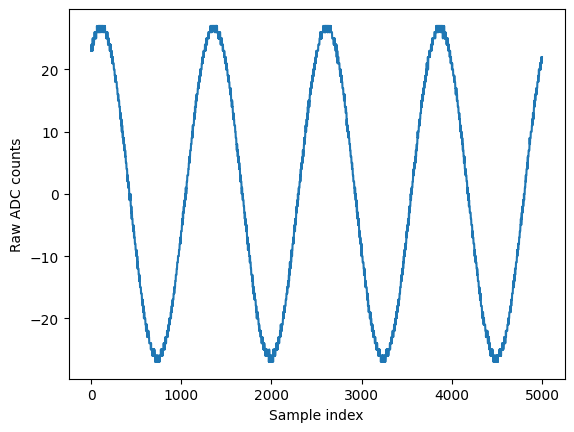

In [21]:
plt.plot(y_raw[:5000])
plt.xlabel("Sample index")
plt.ylabel("Raw ADC counts")
plt.show()

In [18]:
print(my_instrument.query("DATA:ENC?"))
print(my_instrument.query("DATA:WIDTH?"))
print(my_instrument.query("DATA:SOURCE?"))

RIB

1

CH2

